In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp

import sys
sys.path.append("../")

from utils.cart import make_wcs, to_cart

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
hp.npix2nside(len(np.load("../data/fermi_data/template_gce.npy")))

128

In [3]:
NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
print(f'Angular resolution ~ {hp.nside2resol(NSIDE, arcmin=True):.2f} arcmin')
print(f'Number of pixels: {NPIX}')

co_b_s, l_s = hp.pix2ang(NSIDE, range(NPIX))
b_s = np.pi/2 - co_b_s
l_s *= 180/np.pi
b_s *= 180/np.pi

Angular resolution ~ 27.48 arcmin
Number of pixels: 196608


In [4]:
deg_range = 2
cond = np.logical_and(np.logical_or(l_s < deg_range, l_s > 360-deg_range), np.abs(b_s) < deg_range)

center_i_s = []
for i, (l, b) in enumerate(zip(l_s, b_s)):
    if (l < 0.5 or l > 360-0.5) and np.abs(b) < 0.5:
        print(i, l, b)
        center_i_s.append(i)
        
off_center_i = 98562

97536 0.0 0.2984168674869415
98048 0.3515625 0.0
98559 359.6484375 0.0
98560 0.0 -0.2984168674869415


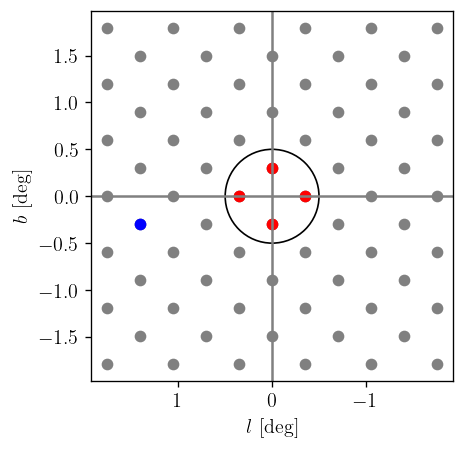

In [5]:
def plot_l(l_s):
    return np.where(l_s > 180, l_s-360, l_s)

fig, ax = plt.subplots()

ax.scatter(plot_l(l_s[cond]), b_s[cond], color='gray')
ax.scatter(plot_l(l_s[center_i_s]), b_s[center_i_s], color='red')
ax.scatter(plot_l(l_s[off_center_i]), b_s[off_center_i], color='blue')
ax.axvline(x=0, color='gray')
ax.axhline(y=0, color='gray')
ax.set(aspect=1)

ax.add_patch(plt.Circle((0,0), 0.5, fc=(0,0,0,0), ec='k'));
xlim = ax.get_xlim()
ax.set(xlim=(xlim[1], xlim[0]))
ax.set(xlabel='$l$ [deg]', ylabel='$b$ [deg]');

## 1. Test map with center delta

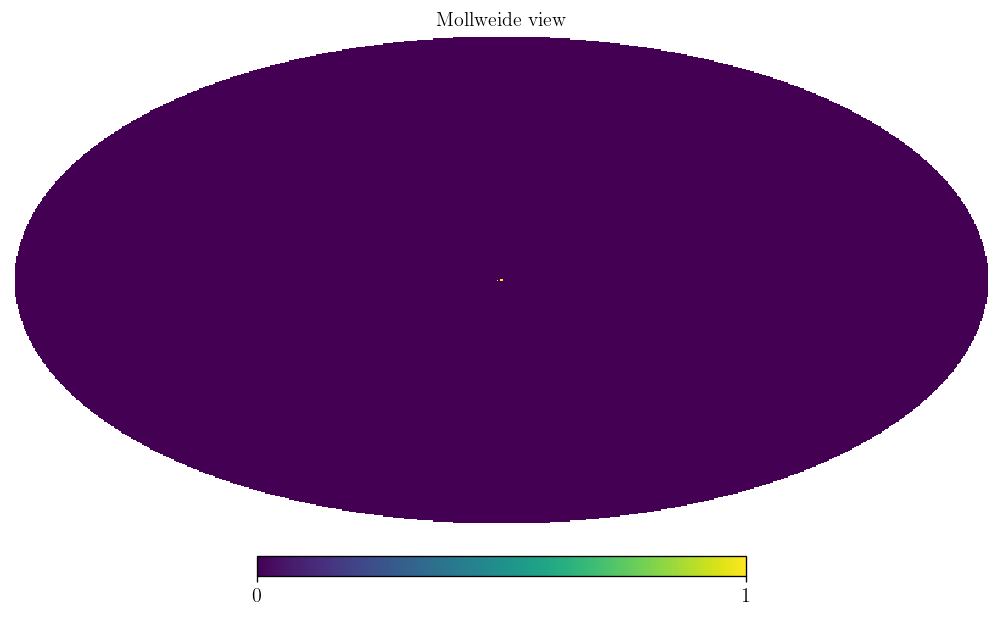

In [6]:
test_map = np.zeros((NPIX,))
test_map[center_i_s] = 1
test_map[off_center_i] = 1
hp.mollview(test_map)

## 2. to_cart offsets

In [ ]:
import numpy as np
from reproject import reproject_from_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

def make_wcs(center, size, pixelsize, frame="Galactic", projection="CAR"):
    xcenter, ycenter = center 
    xsize, ysize = size
    if projection.upper() not in ["TAN", "CAR"]:
        raise ValueError("unsupported projection: " % projection)
    if frame.upper() == "ICRS":
        ctype = ["RA---" + projection.upper(), "DEC--" + projection.upper()]
    elif frame.upper() == "GALACTIC":
        ctype = ["GLON-" + projection.upper(), "GLAT-" + projection.upper()]
    else:
        raise ValueError("unknown frame: " % frame)

    w = WCS(naxis=2)
    w.wcs.ctype = ctype
    w.wcs.crval = np.array([xcenter, ycenter])
    w.wcs.crpix = np.array([xsize / 2.0 - 0.5, ysize / 2.0 - 0.5])
    w.wcs.cdelt = np.array([-pixelsize, pixelsize])
    w.wcs.cunit = ["deg", "deg"]
    w.wcs.equinox = 2000.0
    return w

def to_cart(temp_hp, n_pixels=96, pixelsize=0.5, frame="Galactic", offset=(0.5,-0.5)):
    wcs = make_wcs(center=offset, size=(n_pixels,n_pixels), pixelsize=pixelsize, frame=frame)
    return reproject_from_healpix((temp_hp, "Galactic"), wcs, shape_out=(n_pixels, n_pixels), nested=False)[0]

In [8]:
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

### 2.1 to_cart with no offset

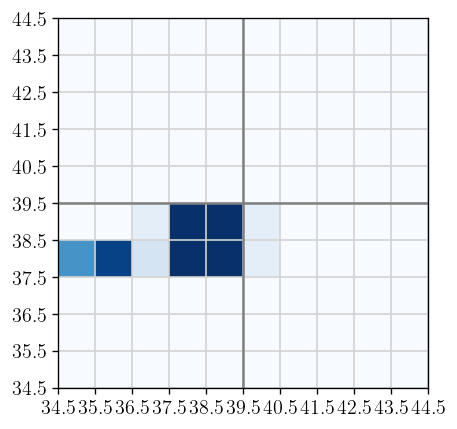

In [9]:
cart_map = to_cart(test_map, n_pixels=80, pixelsize=0.5, offset=(0,0))

fig, ax = plt.subplots()

center_ind = 39.5
show_npix = 5

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=1)
ax.axvline(x=39.5, color='gray')
ax.axhline(y=39.5, color='gray');

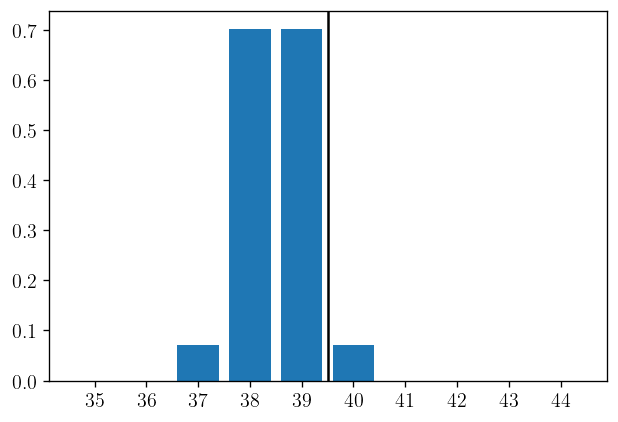

In [10]:
fig, ax = plt.subplots()

plot_v = cart_map[39][35:45]
ax.bar(range(35, 45), plot_v)
ax.set_xticks(range(35, 45))
ax.axvline(x=39.5, color='k');

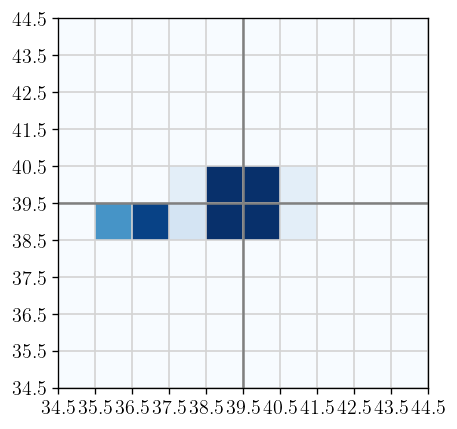

In [12]:
cart_map = to_cart(test_map, n_pixels=80, pixelsize=0.5, offset=(0.5,-0.5))

fig, ax = plt.subplots()

center_ind = 39.5
show_npix = 5

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=1)
ax.axvline(x=39.5, color='gray')
ax.axhline(y=39.5, color='gray');

### 2.2 offset dependent of pixel size

In [25]:
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10

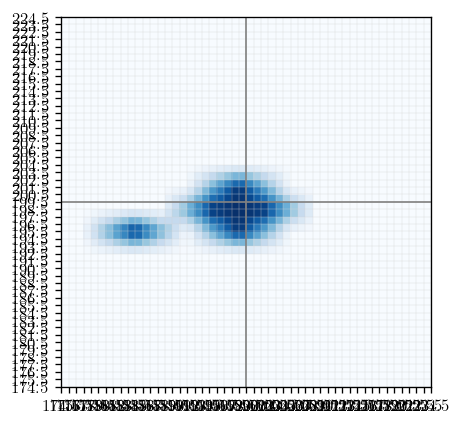

In [26]:
cart_map = to_cart(test_map, n_pixels=400, pixelsize=0.1, offset=(0,0))

fig, ax = plt.subplots()

center_ind = 199.5
show_npix = 25

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=0.2)
ax.axvline(x=199.5, color='gray', linewidth=1)
ax.axhline(y=199.5, color='gray', linewidth=1);

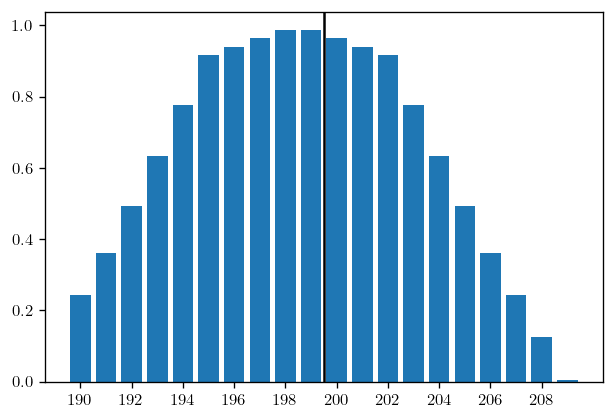

In [27]:
fig, ax = plt.subplots()

plot_v = cart_map[199][190:210]

ax.bar(range(190, 210), plot_v)
ax.set_xticks(range(190, 210, 2))
ax.axvline(x=199.5, color='k');

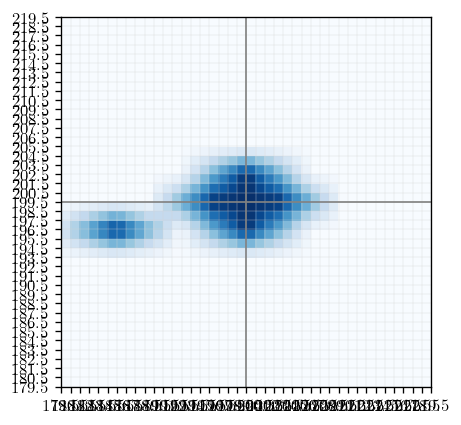

In [28]:
cart_map = to_cart(test_map, n_pixels=400, pixelsize=0.1, offset=(0.1,-0.1))

fig, ax = plt.subplots()

center_ind = 199.5
show_npix = 20

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=0.2)
ax.axvline(x=199.5, color='gray', linewidth=1)
ax.axhline(y=199.5, color='gray', linewidth=1);

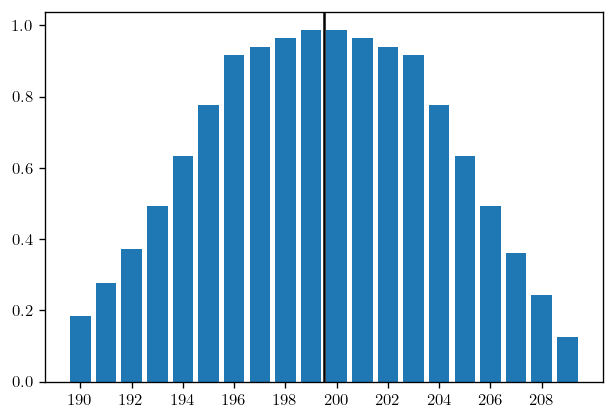

In [29]:
fig, ax = plt.subplots()

plot_v = cart_map[199][190:210]

ax.bar(range(190, 210), plot_v)
ax.set_xticks(range(190, 210, 2))
ax.axvline(x=199.5, color='k');

changed default offset to offset=(pixelsize,-pixelsize)

## 3. Modified to_cart

In [36]:
import numpy as np
from reproject import reproject_from_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [37]:
def make_wcs(center, size, pixelsize, frame="Galactic", projection="CAR"):
    xcenter, ycenter = center 
    xsize, ysize = size
    if projection.upper() not in ["TAN", "CAR"]:
        raise ValueError("unsupported projection: " % projection)
    if frame.upper() == "ICRS":
        ctype = ["RA---" + projection.upper(), "DEC--" + projection.upper()]
    elif frame.upper() == "GALACTIC":
        ctype = ["GLON-" + projection.upper(), "GLAT-" + projection.upper()]
    else:
        raise ValueError("unknown frame: " % frame)

    w = WCS(naxis=2)
    w.wcs.ctype = ctype
    w.wcs.crval = np.array([xcenter, ycenter])
    w.wcs.crpix = np.array([xsize / 2.0 + 0.5, ysize / 2.0 + 0.5])
    w.wcs.cdelt = np.array([-pixelsize, pixelsize])
    w.wcs.cunit = ["deg", "deg"]
    w.wcs.equinox = 2000.0
    return w

def to_cart_2(temp_hp, n_pixels=96, pixelsize=0.5, frame="Galactic"):
    wcs = make_wcs(center=(0., 0.), size=(n_pixels,n_pixels), pixelsize=pixelsize, frame=frame)
    return reproject_from_healpix((temp_hp, "Galactic"), wcs, shape_out=(n_pixels, n_pixels), nested=False)[0]

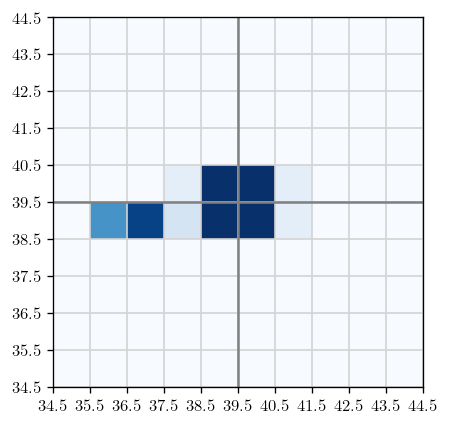

In [39]:
cart_map = to_cart_2(test_map, n_pixels=80, pixelsize=0.5)

fig, ax = plt.subplots()

center_ind = 39.5
show_npix = 5

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=1)
ax.axvline(x=39.5, color='gray')
ax.axhline(y=39.5, color='gray');

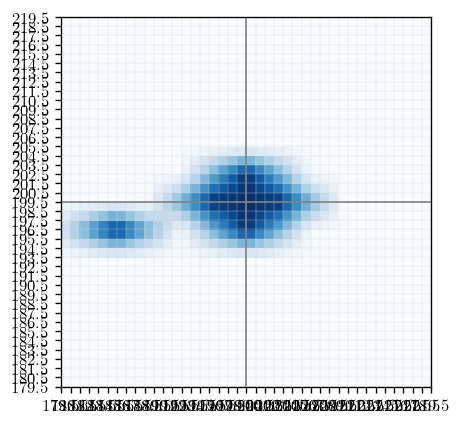

In [38]:
cart_map = to_cart_2(test_map, n_pixels=400, pixelsize=0.1)

fig, ax = plt.subplots()

center_ind = 199.5
show_npix = 20

ax.imshow(cart_map, interpolation=None, cmap='Blues')
ax.set(xlim = (center_ind-show_npix, center_ind+show_npix),
       ylim = (center_ind-show_npix, center_ind+show_npix))
ax.set_xticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.set_yticks(0.5+np.arange(int(center_ind-show_npix), 1+int(center_ind+show_npix)))
ax.grid(color='lightgray', linestyle='-', linewidth=0.2)
ax.axvline(x=199.5, color='gray', linewidth=1)
ax.axhline(y=199.5, color='gray', linewidth=1);